In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
df = pd.read_csv("bali_tourist_destination.csv")

print("LOAD DATA")

df = pd.read_csv('bali_tourist_destination.csv')
print(f'Shape   : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Kolom   : {df.columns.tolist()}')
df.head()

LOAD DATA
Shape   : 1452 baris x 11 kolom
Kolom   : ['id_tempat', 'nama_tempat_wisata', 'kategori', 'kecamatan', 'kabupaten_kota', 'rating', 'jumlah_rating', 'latitude', 'longitude', 'link_google_maps', 'link_gambar']


,id_tempat,nama_tempat_wisata,kategori,kecamatan,kabupaten_kota,rating,jumlah_rating,latitude,longitude,link_google_maps,link_gambar
0,BL0101001,Patung Titi Banda,Umum,Denpasar Barat,Kota Denpasar,4.6,1941,-8.649292,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
1,BL0101002,Uma.palak.(parkir.2),Rekreasi,Denpasar Barat,Kota Denpasar,4.8,83,-8.617877,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...
2,BL0101003,Tukad Bindu Park,Rekreasi,Denpasar Barat,Kota Denpasar,4.5,1180,-8.643791,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
3,BL0101004,Pantai Padang Galak,Alam,Denpasar Barat,Kota Denpasar,4.6,486,-8.661138,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
4,BL0101005,Museum Le Mayeur,Budaya,Denpasar Barat,Kota Denpasar,4.1,679,-8.674877,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...


# **Cek Missing Value**

In [3]:
print("MISSING VALUE")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({"Jumlah Missing": missing, "Persentase (%)": missing_pct})
print(mv_df[mv_df["Jumlah Missing"] > 0].to_string())

MISSING VALUE
             Jumlah Missing  Persentase (%)
link_gambar               4            0.28


# **Cek Data Duplikat**

In [4]:
print("DUPLIKAT")

dup_count = df.duplicated().sum()
print(f"Jumlah baris duplikat : {dup_count}")

DUPLIKAT
Jumlah baris duplikat : 0


# **EDA**

In [5]:
print("STATISTIK DESKRIPTIF")

print(df[["rating", "jumlah_rating"]].describe().to_string())
print(f"\nCatatan: {(df['rating'] == 0).sum()} tempat memiliki rating = 0 (belum ada ulasan)")

STATISTIK DESKRIPTIF
            rating  jumlah_rating
count  1452.000000    1452.000000
mean      4.505028    1176.176997
std       0.561069    5268.544496
min       0.000000       0.000000
25%       4.400000      24.000000
50%       4.600000     110.000000
75%       4.800000     472.000000
max       5.000000  101523.000000

Catatan: 15 tempat memiliki rating = 0 (belum ada ulasan)


In [6]:
print("DISTRIBUSI KATEGORI WISATA")

kat_dist = df["kategori"].value_counts()
print(kat_dist.to_string())

DISTRIBUSI KATEGORI WISATA
kategori
Umum        577
Alam        529
Budaya      182
Rekreasi    164


In [7]:
print("DISTRIBUSI RATING")

rating_dist = df["rating"].value_counts().sort_index()
print(rating_dist.to_string())

DISTRIBUSI RATING
rating
0.0     15
2.0      1
3.0      7
3.1      1
3.2      1
3.3      3
3.4      3
3.5      4
3.6      6
3.7      9
3.8      8
3.9     14
4.0     30
4.1     35
4.2     51
4.3    114
4.4    153
4.5    203
4.6    220
4.7    208
4.8    133
4.9     96
5.0    137


# **Viasualisasi Data**

VISUALISASI DISTRIBUSI DATA


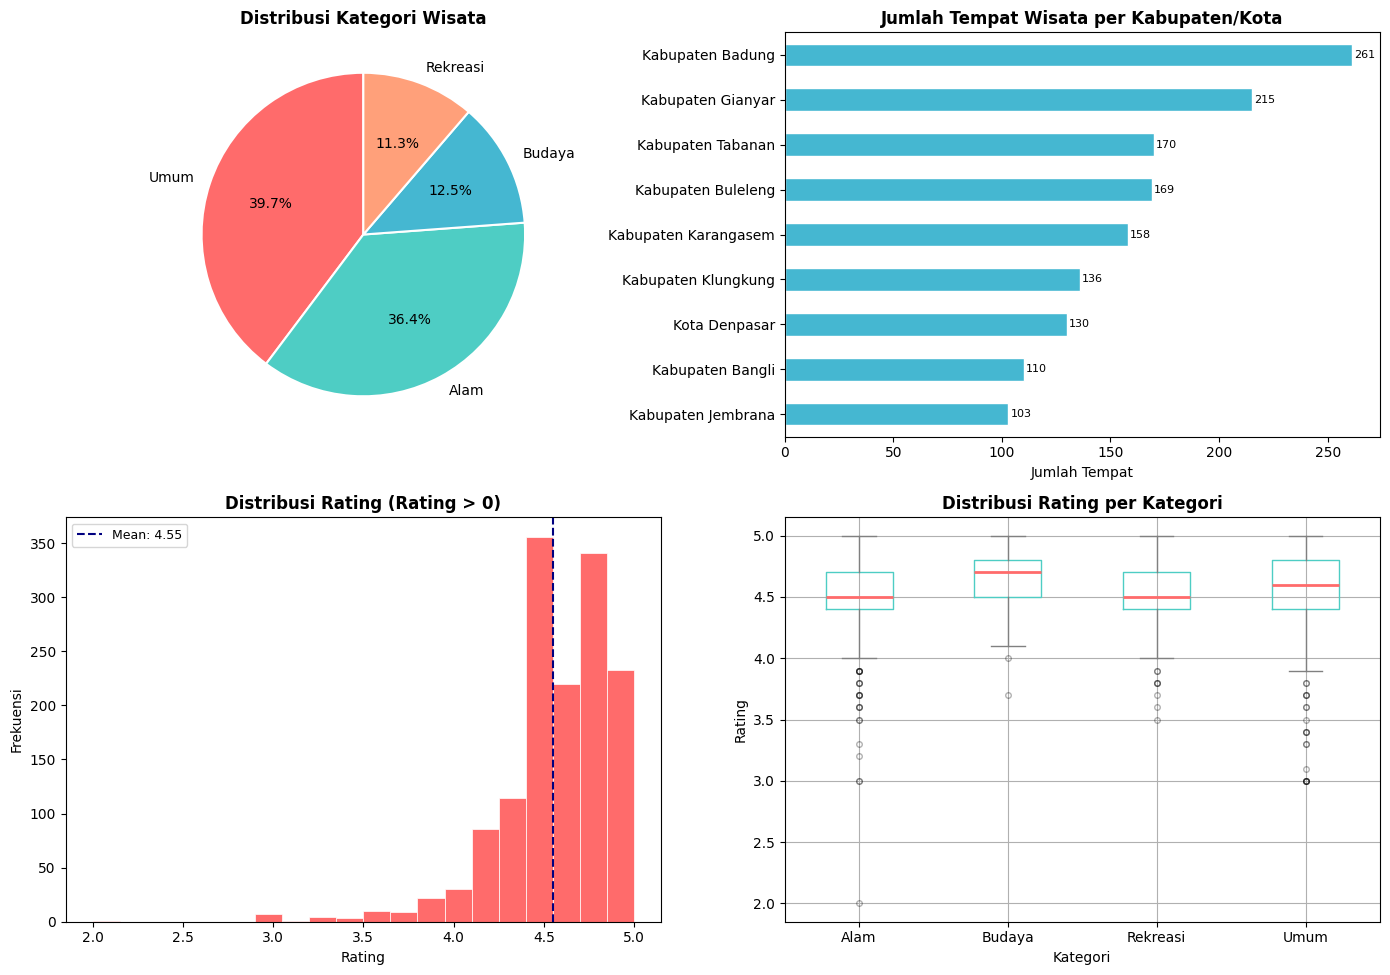

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Bali Tourist Destination", fontsize=16, fontweight="bold", y=1.01)

ax = axes[0, 0]
colors_pie = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A"]
kat_dist.plot(kind="pie", ax=ax, autopct="%1.1f%%", colors=colors_pie,
              startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_ylabel("")
ax.set_title("Distribusi Kategori Wisata", fontweight="bold")

ax = axes[0, 1]
kab_dist = df["kabupaten_kota"].value_counts()
kab_dist.sort_values().plot(kind="barh", ax=ax, color="#45B7D1", edgecolor="white")
ax.set_title("Jumlah Tempat Wisata per Kabupaten/Kota", fontweight="bold")
ax.set_xlabel("Jumlah Tempat")
ax.set_ylabel("")
for bar in ax.patches:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            int(bar.get_width()), va="center", fontsize=8)

ax = axes[1, 0]
df_nonzero = df[df["rating"] > 0]
ax.hist(df_nonzero["rating"], bins=20, color="#FF6B6B", edgecolor="white", linewidth=0.5)
ax.set_title("Distribusi Rating (Rating > 0)", fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Frekuensi")
ax.axvline(df_nonzero["rating"].mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f'Mean: {df_nonzero["rating"].mean():.2f}')
ax.legend(fontsize=9)

ax = axes[1, 1]
df_nonzero.boxplot(column="rating", by="kategori", ax=ax,
                   boxprops=dict(color="#4ECDC4"),
                   medianprops=dict(color="#FF6B6B", linewidth=2),
                   whiskerprops=dict(color="gray"),
                   capprops=dict(color="gray"),
                   flierprops=dict(marker="o", color="gray", alpha=0.3, markersize=4))
ax.set_title("Distribusi Rating per Kategori", fontweight="bold")
ax.set_xlabel("Kategori")
ax.set_ylabel("Rating")
plt.sca(ax)
plt.title("Distribusi Rating per Kategori", fontweight="bold")
fig.suptitle("")

plt.tight_layout()
plt.savefig("eda_visualisasi.png", dpi=150, bbox_inches="tight")
print("VISUALISASI DISTRIBUSI DATA")
plt.show()



# **Data Cleaning**

In [9]:
print(" DATA CLEANING")

df_clean = df.copy()

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Hapus duplikat       : {before - len(df_clean)} baris dihapus")

df_clean["link_gambar"].fillna("https://via.placeholder.com/400x300?text=No+Image", inplace=True)
print(f"Isi missing link_gambar : {df['link_gambar'].isnull().sum()} → 0")

median_per_kat = df_clean[df_clean["rating"] > 0].groupby("kategori")["rating"].median()
zero_idx = df_clean[df_clean["rating"] == 0].index
for idx in zero_idx:
    kat = df_clean.loc[idx, "kategori"]
    df_clean.loc[idx, "rating"] = median_per_kat[kat]
print(f"Handle rating = 0    : {len(zero_idx)} baris diisi median per kategori")

print(f"\nShape setelah cleaning : {df_clean.shape}")
print("Missing value sisa:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_string()
      if df_clean.isnull().sum().sum() > 0 else "Tidak ada missing value")

 DATA CLEANING
Hapus duplikat       : 0 baris dihapus
Isi missing link_gambar : 4 → 0
Handle rating = 0    : 15 baris diisi median per kategori

Shape setelah cleaning : (1452, 11)
Missing value sisa:
Tidak ada missing value


In [10]:
print("TEXT PREPROCESSING")

STOPWORDS_ID = {
    "di", "ke", "dari", "dan", "atau", "yang", "ini", "itu", "adalah",
    "dengan", "untuk", "pada", "oleh", "tidak", "ada", "juga", "sangat",
    "bisa", "akan", "dalam", "sudah", "bagi", "kami", "kita", "anda",
    "saya", "mereka", "ia", "kamu", "tersebut", "serta", "namun", "tetapi",
    "tapi", "jika", "karena", "seperti", "lebih", "sudah", "masih",
    "sebuah", "setiap", "lain", "nya", "pun", "pula", "kini"
}

def preprocess_text(text: str) -> str:
    # Lowercase
    text = str(text).lower()
    # Hapus karakter non-alfabet (simbol, angka, tanda baca)
    text = re.sub(r"[^a-z\s]", " ", text)
    # Hapus extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Hapus stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ID]
    return " ".join(tokens)

df_clean["nama_clean"] = df_clean["nama_tempat_wisata"].apply(preprocess_text)
df_clean["kategori_clean"] = df_clean["kategori"].apply(preprocess_text)
df_clean["kecamatan_clean"] = df_clean["kecamatan"].apply(preprocess_text)
df_clean["kabupaten_clean"] = df_clean["kabupaten_kota"].apply(preprocess_text)

df_clean["fitur_gabungan"] = (
    df_clean["nama_clean"] + " " +
    df_clean["kategori_clean"] + " " +
    df_clean["kecamatan_clean"] + " " +
    df_clean["kabupaten_clean"]
)

print('Contoh hasil preprocessing:')
df_clean[['nama_tempat_wisata','fitur_gabungan']].head()

TEXT PREPROCESSING
Contoh hasil preprocessing:


,nama_tempat_wisata,fitur_gabungan
0,Patung Titi Banda,patung titi banda umum denpasar barat kota den...
1,Uma.palak.(parkir.2),uma palak parkir rekreasi denpasar barat kota ...
2,Tukad Bindu Park,tukad bindu park rekreasi denpasar barat kota ...
3,Pantai Padang Galak,pantai padang galak alam denpasar barat kota d...
4,Museum Le Mayeur,museum le mayeur budaya denpasar barat kota de...


#Conten Based

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import pandas as pd

# 1. Inisialisasi fungsi TF-IDF Vectorizer
tf = TfidfVectorizer()

# 2. Mengubah data tekstual 'fitur_gabungan' dari df_clean menjadi bentuk matriks angka
tfidf_matrix = tf.fit_transform(df_clean['fitur_gabungan'])

# Menampilkan dimensi matriks hasil TF-IDF (jumlah_baris_data, jumlah_kata_unik_yang_ditemukan)
print('Ukuran Matriks TF-IDF:', tfidf_matrix.shape)

Ukuran Matriks TF-IDF: (1452, 1703)


In [12]:
cosine_sim = cosine_similarity(tfidf_matrix)

cosine_sim_df = pd.DataFrame(cosine_sim, index=df_clean['nama_tempat_wisata'], columns=df_clean['nama_tempat_wisata'])
print('Ukuran Cosine Similarity DataFrame:', cosine_sim_df.shape)

Ukuran Cosine Similarity DataFrame: (1452, 1452)


In [13]:
def bali_recommendations_by_category(kategori_pilihan, similarity_data=cosine_sim_df, items=df_clean, k=10,
                                     filter_kabupaten=None, min_rating=0.0):

    # Mencari semua tempat wisata yang memiliki kategori sesuai dengan input pilihan user
    matching_items = items[items['kategori'].str.lower() == kategori_pilihan.lower()]

    # Jika kategori tidak ditemukan di dataset
    if matching_items.empty:
        return f"Kategori '{kategori_pilihan}' tidak ditemukan dalam dataset."

    # Mengambil semua tempat dari kategori
    recommendations = matching_items.copy()

    # Mengurutkan berdasarkan skor rating tertinggi
    recommendations = recommendations.sort_values(by='rating', ascending=False)

    # Menyaring data berdasarkan wilayah kabupaten_kota
    if filter_kabupaten and filter_kabupaten != "Semua Kabupaten/Kota":
        recommendations = recommendations[recommendations['kabupaten_kota'].str.lower() == filter_kabupaten.lower()]

    # Menyaring kembali data hasil filter lokasi agar hanya memunculkan rating sesuai
    recommendations = recommendations[recommendations['rating'] >= min_rating]

    output_df = recommendations[['nama_tempat_wisata', 'kategori', 'kecamatan', 'kabupaten_kota', 'rating', 'jumlah_rating']].head(k)
    output_df = output_df.rename(columns={
        'nama_tempat_wisata': 'Nama Tempat Wisata',
        'kategori': 'Kategori',
        'kecamatan': 'Kecamatan',
        'kabupaten_kota': 'Kabupaten/Kota',
        'rating': 'Rating',
        'jumlah_rating': 'Jumlah Rating'
    })

    return output_df

In [14]:
target_kategori = 'Alam'

print(f"Kategori Wisata yang Dipilih Pengguna: {target_kategori}")
display(bali_recommendations_by_category(target_kategori, k=10))

Kategori Wisata yang Dipilih Pengguna: Alam


,Nama Tempat Wisata,Kategori,Kecamatan,Kabupaten/Kota,Rating,Jumlah Rating
971,Tujuan wisata gunung batur,Alam,Kintamani,Kabupaten Bangli,5.0,1
1110,Pantai Pesinggahan,Alam,Dawan,Kabupaten Klungkung,5.0,4
974,"Tugu TWA Gunung Batur, Bukit Payang",Alam,Kintamani,Kabupaten Bangli,5.0,1
970,Gunung batur,Alam,Kintamani,Kabupaten Bangli,5.0,16
308,LAGUNA BEACH BALI,Alam,Kuta Utara,Kabupaten Badung,5.0,5
708,Baturiti Bersemi Desa Wisata,Alam,Kerambitan,Kabupaten Tabanan,5.0,1
726,pantai kuta,Alam,Marga,Kabupaten Tabanan,5.0,2
751,pertigaan sawah--belimbing,Alam,Selemadeg Barat,Kabupaten Tabanan,5.0,1
760,LOVE RIVE WATERFALL,Alam,Selemadeg Barat,Kabupaten Tabanan,5.0,4
913,Cekik Amerta Bhuana Waterfall,Alam,Sukasada,Kabupaten Buleleng,5.0,15


In [15]:
display(bali_recommendations_by_category(target_kategori, filter_kabupaten='Kota Denpasar', min_rating=4.5, k=5))

,Nama Tempat Wisata,Kategori,Kecamatan,Kabupaten/Kota,Rating,Jumlah Rating
113,Pantai Campuhan,Alam,Denpasar Timur,Kota Denpasar,5.0,6
94,Pura Campuhan Windhu Segara Padanggalak Denpasar,Alam,Denpasar Timur,Kota Denpasar,4.8,220
105,Pantai Dermaga,Alam,Denpasar Timur,Kota Denpasar,4.8,20
13,Pantai Double - Six,Alam,Denpasar Barat,Kota Denpasar,4.7,2038
66,Segara Ayu Beach,Alam,Denpasar Selatan,Kota Denpasar,4.7,66


In [16]:
with open('bali_rec_model.pkl', 'wb') as f:
    pickle.dump({
        'dataframe': df_clean,
        'similarity_df': cosine_sim_df
    }, f)
print("File 'bali_rec_model.pkl' sukses diexport")

File 'bali_rec_model.pkl' sukses diexport
